# EMTscore Analysis and Plots (automated)

This notebook is a thin front-end. Every cell is a one-liner call into
`emtscore.workflow`, which contains the same logic as
`EMTScore_workflow_clean_v2.ipynb` (heavy code lifted out into Python_Conv).

## 2. Example Walkthrough (Bulk RNA-seq)


### 0. Environment

In [20]:
# Make the EMTScorePy package importable from anywhere
import sys
from pathlib import Path
PKG_ROOT = Path.cwd().resolve()
while not (PKG_ROOT / 'emtscore').is_dir():
    if PKG_ROOT == PKG_ROOT.parent:
        break
    PKG_ROOT = PKG_ROOT.parent
sys.path.insert(0, str(PKG_ROOT))
print('Package root:', PKG_ROOT)


Package root: C:\Users\shawn\Downloads\Github\EMTScorePy


In [21]:
%matplotlib inline
from IPython.display import display
from emtscore import workflow as wf


### 2.1 - 2.4 Load cell annotation, gene expression, signatures, GMT

In [22]:
inp = wf.load_inputs()
display(inp.cell_annot.head())
display(inp.geneExp.iloc[:4, :5])
display(inp.E_sig.head())
display(inp.M_sig.head())


geneExp shape: (120, 15950)  (samples × genes)
E signature: (232, 1)
M signature: (193, 1)
GMT saved: C:\Users\shawn\Downloads\Github\EMTScorePy\data\EM_signature.gmt


,name,source,celltype_annotation
0,c.COLO668,CCLE,A2
1,c.CORL24,CCLE,A
2,c.CORL279,CCLE,A
3,c.CORL311,CCLE,P
4,c.CORL47,CCLE,A


,A1BG,A1CF,A2M,A2ML1,A4GALT
m.DMS153,2.955199,0.077212,2.267502,0.011011,2.453512
m.NCIH60,3.239727,0.167166,0.122302,-0.007241,1.528297
m.NCIH69,3.599770,0.117398,0.085891,-0.005086,1.428711
m.NCIH82,3.055231,0.536179,1.586479,-0.004471,0.359365


,GeneName
0,ABCC3
1,ABHD11
2,ADAP1
3,AGR2
4,CRYBG1


,GeneName
0,AKAP12
1,AKAP2
2,AKT3
3,ANGPTL2
4,ANK2


### 2.5 Compute Scores Using Multiple Methods

In [23]:
scores = wf.score_all_methods(inp.geneExp, inp.gmt_path)
display(scores.comparison.head())


nnPCA  : (120, 1) ['EMT_score']
AUCell : (120, 2) ['Panchy_et_al_E_signature', 'Panchy_et_al_M_signature']
ssGSEA : (120, 2) ['Panchy_et_al_E_signature', 'Panchy_et_al_M_signature']
              nnPCA    AUCell    ssGSEA
m.DMS153   1.298978  0.436911  0.461406
m.NCIH60  -1.658487 -0.991991 -0.341275
m.NCIH69   0.378246 -0.252090 -0.245818
m.NCIH82  -1.442508 -0.517208 -0.283537
m.NCIH128  0.566087  0.329044 -0.127615


,nnPCA,AUCell,ssGSEA
m.DMS153,1.298978,0.436911,0.461406
m.NCIH60,-1.658487,-0.991991,-0.341275
m.NCIH69,0.378246,-0.252090,-0.245818
m.NCIH82,-1.442508,-0.517208,-0.283537
m.NCIH128,0.566087,0.329044,-0.127615


### 2.6 Prepare Data for Plotting

In [24]:
pd_data = wf.prepare_plot_dataframes(scores, inp.geneExp, inp.M_sig, inp.cell_annot)


All data prepared. Shapes:
  nnPCA_em:   (118, 3)
  aucell_em:  (118, 4)
  ssgsea_em:  (118, 4)
  nnPCA_mm:   (118, 4)


### 2.7 E Score vs M Score Plot

Scatter plot with KDE contours and mean ± SD markers per cell type.


In [25]:
print(pd_data.nnPCA_em.head())


          source celltype_annotation  EMT_score
m.DMS153   Minna                  A2  18.014337
m.NCIH60   Minna                   N -23.000036
m.NCIH69   Minna                   A   5.245544
m.NCIH128  Minna                   A   7.850546
m.NCIH146  Minna                   A   7.592811


In [26]:
# Re-align indices and recompute nnPCA per gene set (v2 cell 16)
rb = wf.rebuild_em_for_plot(inp.geneExp, inp.cell_annot, inp.gmt_path)


nnPCA_em columns: ['Panchy_et_al_E_signature', 'Panchy_et_al_M_signature', 'celltype_annotation']
aucell_em columns: ['Panchy_et_al_E_signature', 'Panchy_et_al_M_signature', 'celltype_annotation']
ssgsea_em columns: ['Panchy_et_al_E_signature', 'Panchy_et_al_M_signature', 'celltype_annotation']


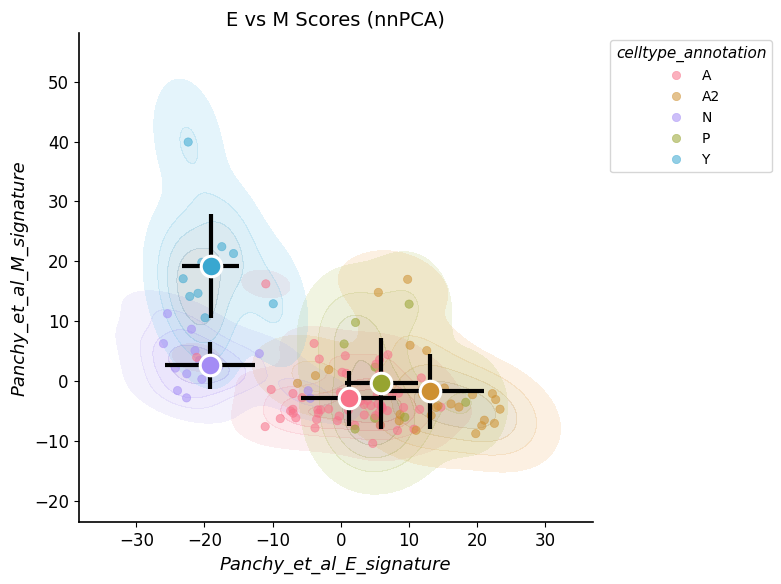

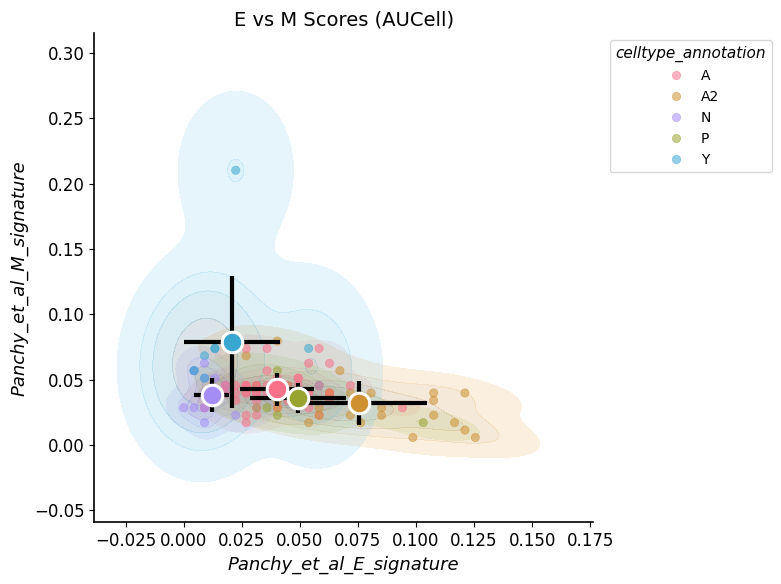

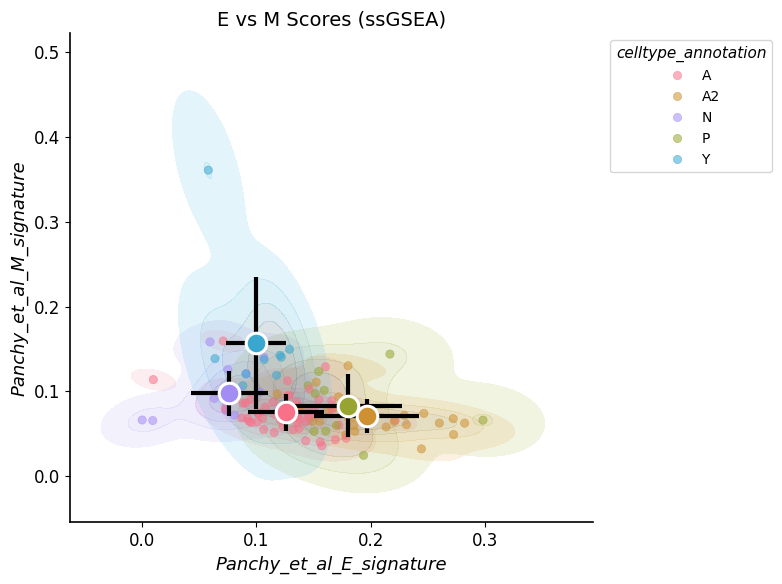

In [27]:
# Three E-vs-M panels: nnPCA, AUCell, ssGSEA
for fig in wf.plot_em_section(rb):
    if fig is not None:
        display(fig)


### 2.8 M1 vs M2 Score Plot

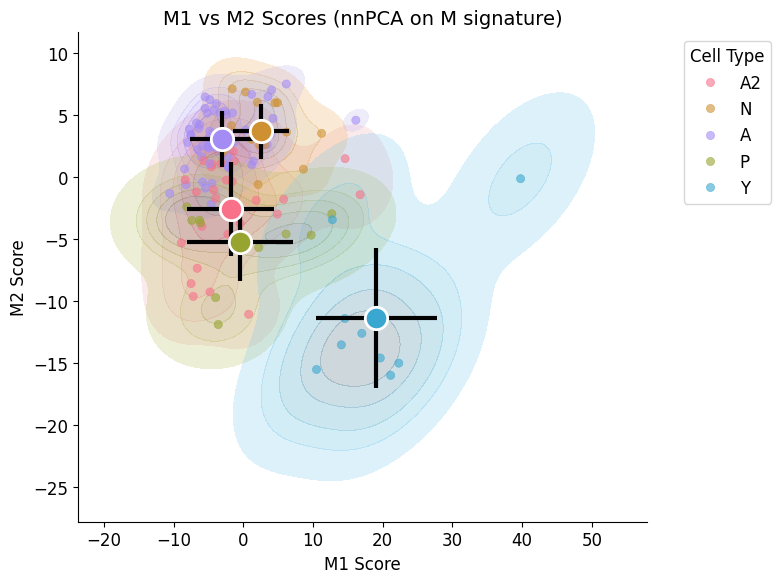

In [28]:
display(wf.plot_m1_m2(pd_data.nnPCA_mm))


### 2.9 Combined Plot (E vs M  |  M1 vs M2)

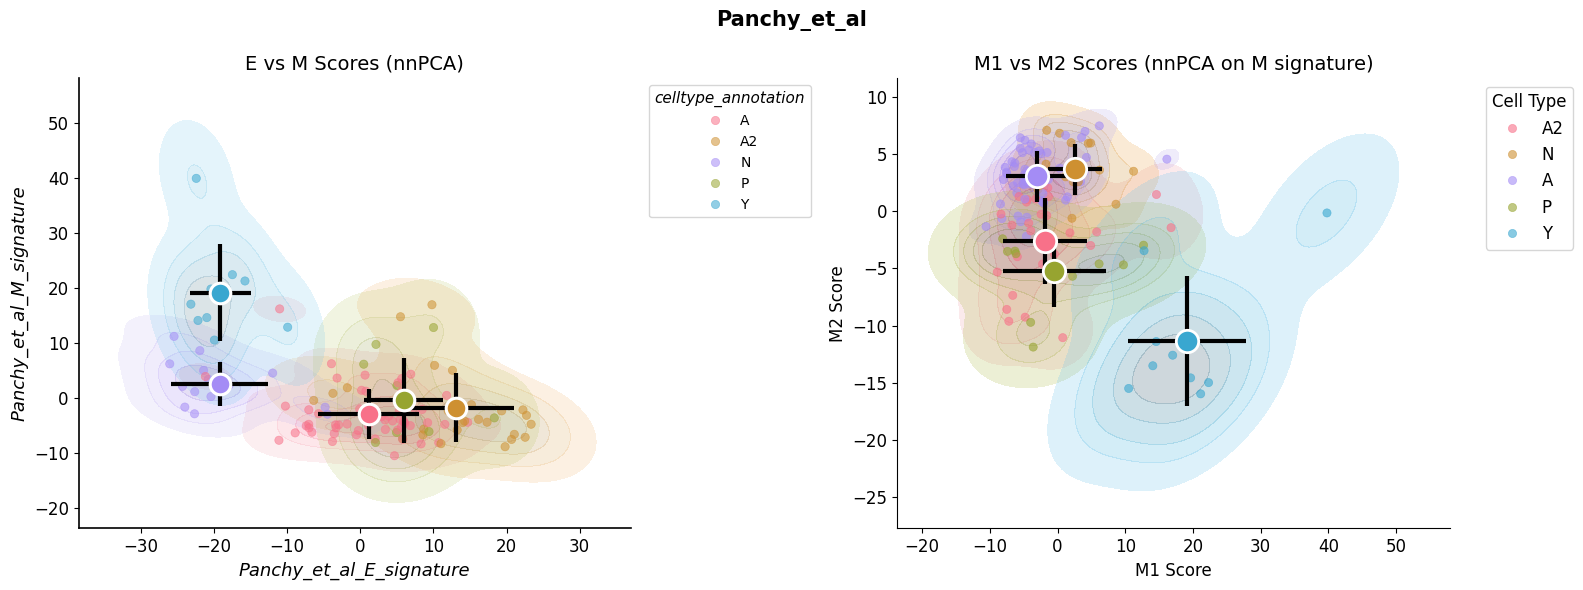

In [29]:
display(wf.plot_combined_em_m1_m2(rb.nnPCA_em, pd_data.nnPCA_mm))


### 2.10 E/M Score Distributions (M1 Histogram)

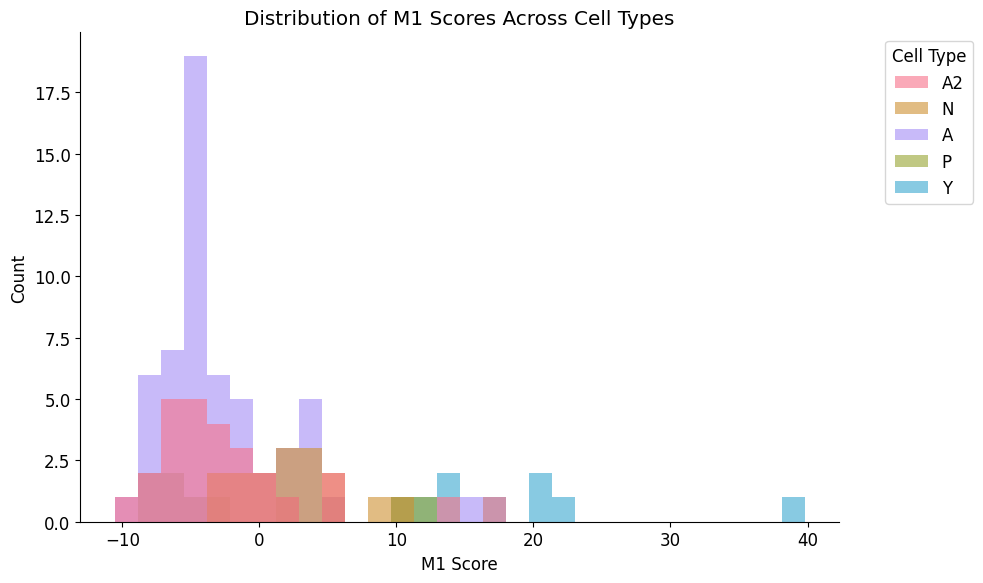

In [30]:
display(wf.plot_m1_histogram(pd_data.nnPCA_mm))


### 2.11 Heatmap (M Signature Genes, Hierarchically Clustered)

#### 2.11.0 Full M-Signature Heatmap (All Genes)

Full-M heatmap: 176 of 193 signature genes present


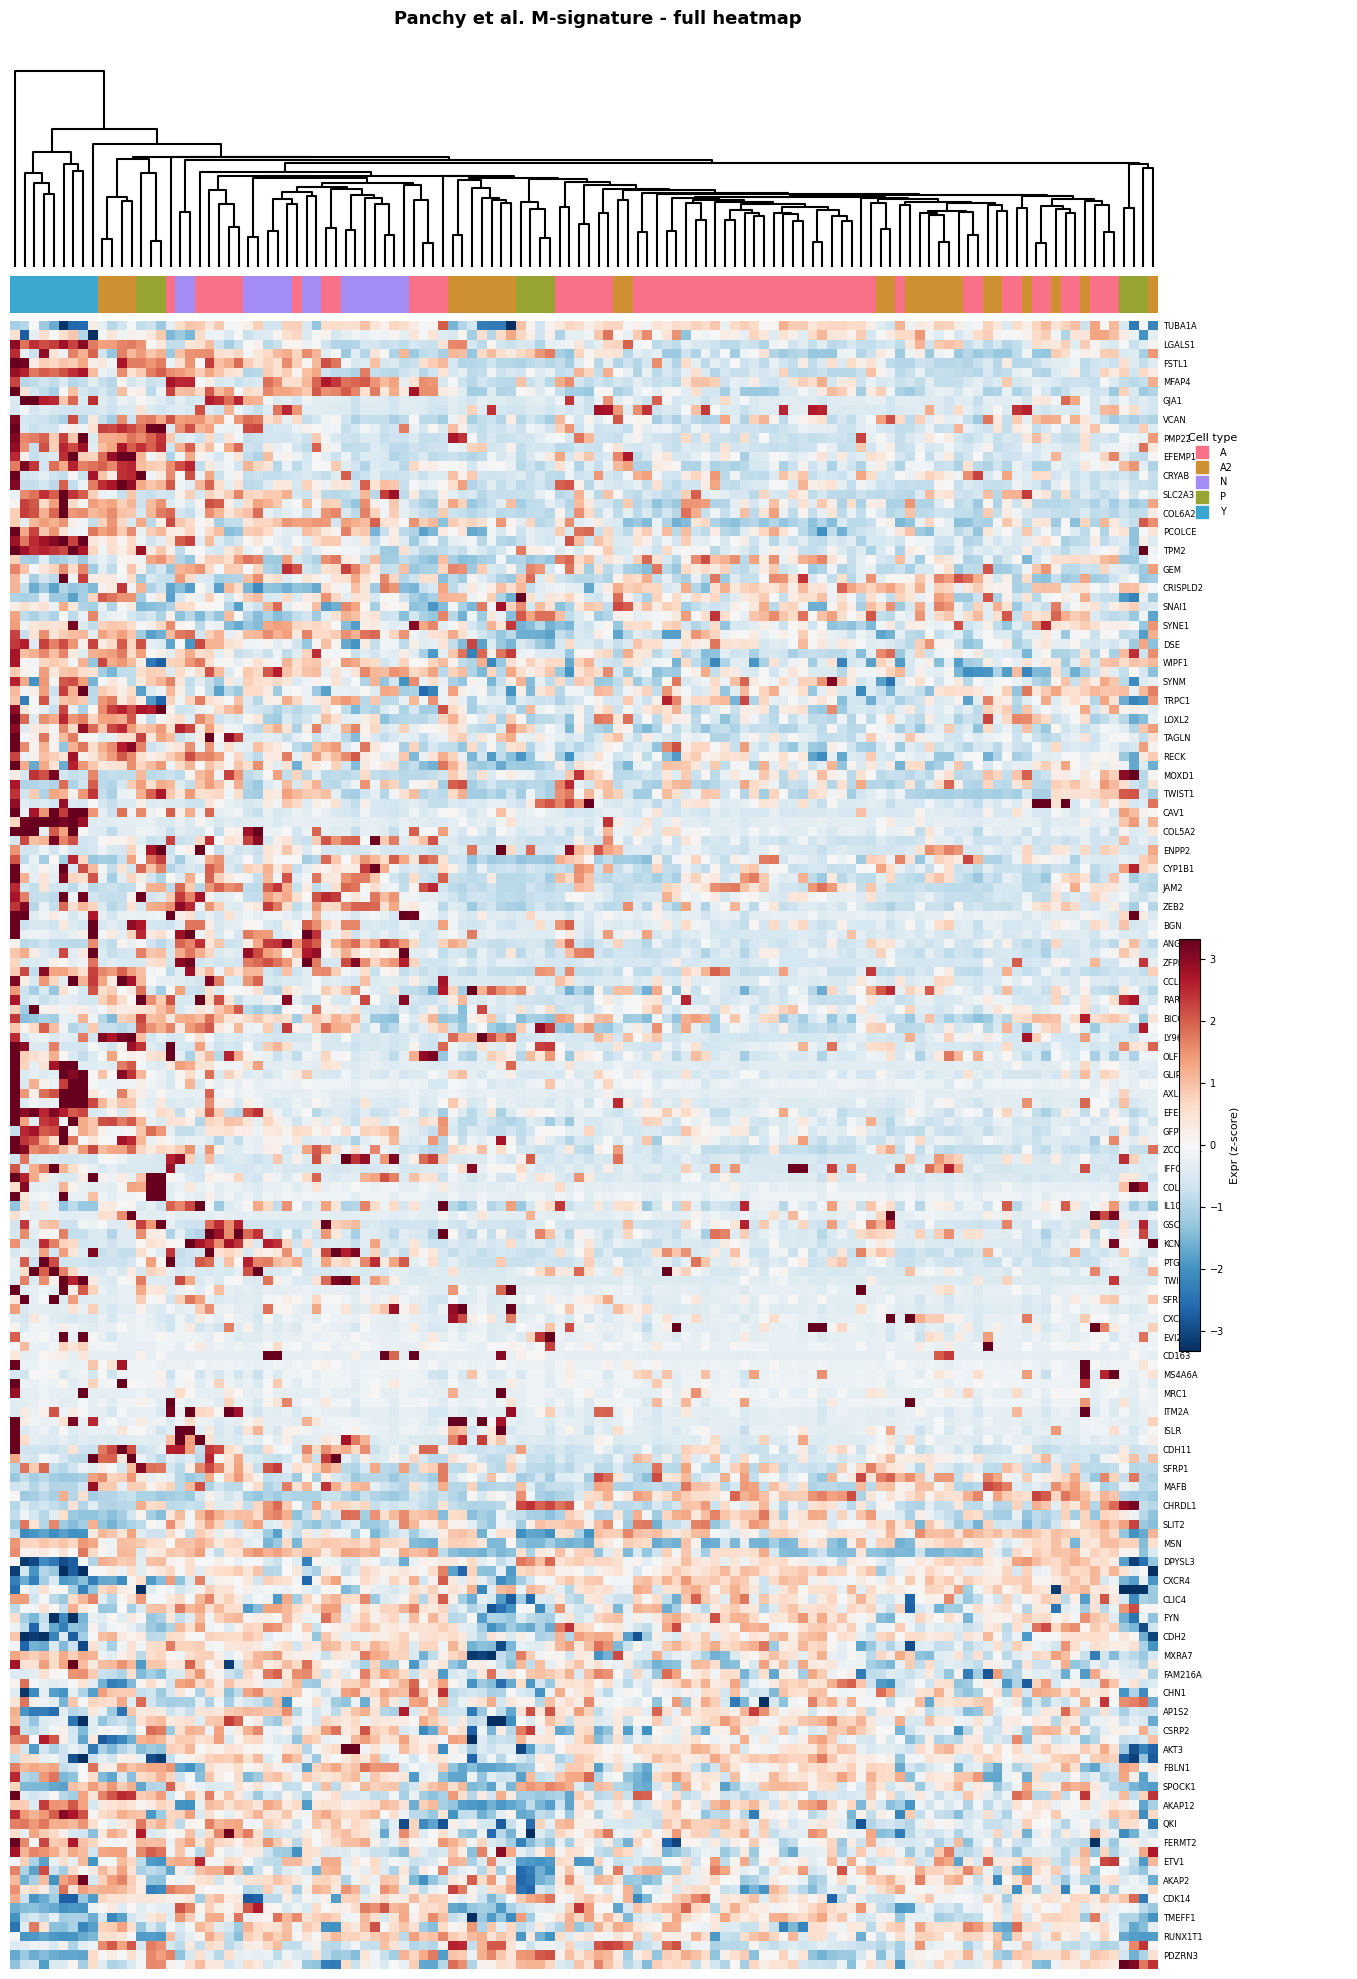

In [31]:
display(wf.plot_full_m_heatmap(rb.geneExp, inp.M_sig, rb.nnPCA_em))


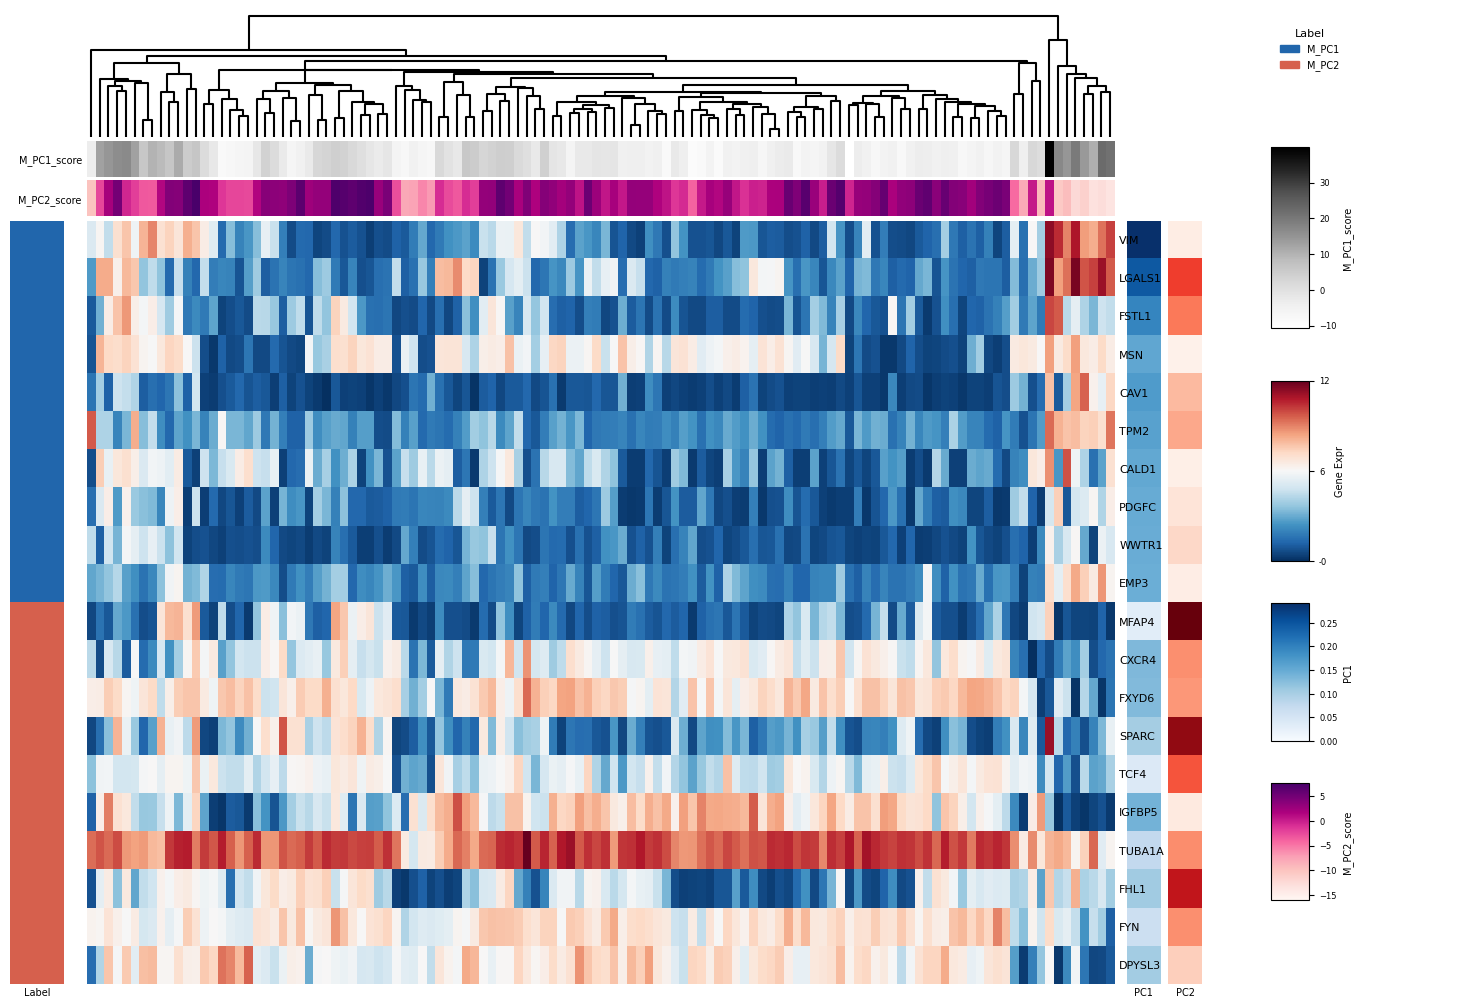

In [32]:
display(wf.plot_pc_driver_heatmap(rb.geneExp, inp.M_sig, rb.nnPCA_em, pd_data.nnPCA_mm))


---
## 3. Example Walkthrough: Single-Cell RNA-seq


### 3.1 Data Importing and Basic Calculations

In [33]:
adatas = wf.load_cook_adatas()


A549_EGF: (12435, 289),  Pseudotime: 0.000 - 1.000
A549_TGFB1: (3568, 295),  Pseudotime: 0.000 - 1.000
A549_TNF: (12911, 289),  Pseudotime: 0.000 - 1.000


#### 3.1.1 EMT score across pseudotime per condition

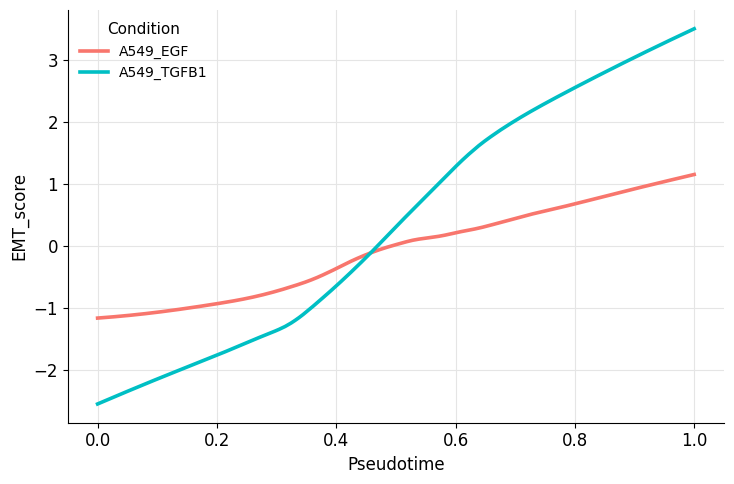

In [34]:
display(wf.plot_emt_vs_pseudotime(['A549_EGF', 'A549_TGFB1']))


### 3.2 Building Gaussian Mixture Models (GMM) in E-M Space

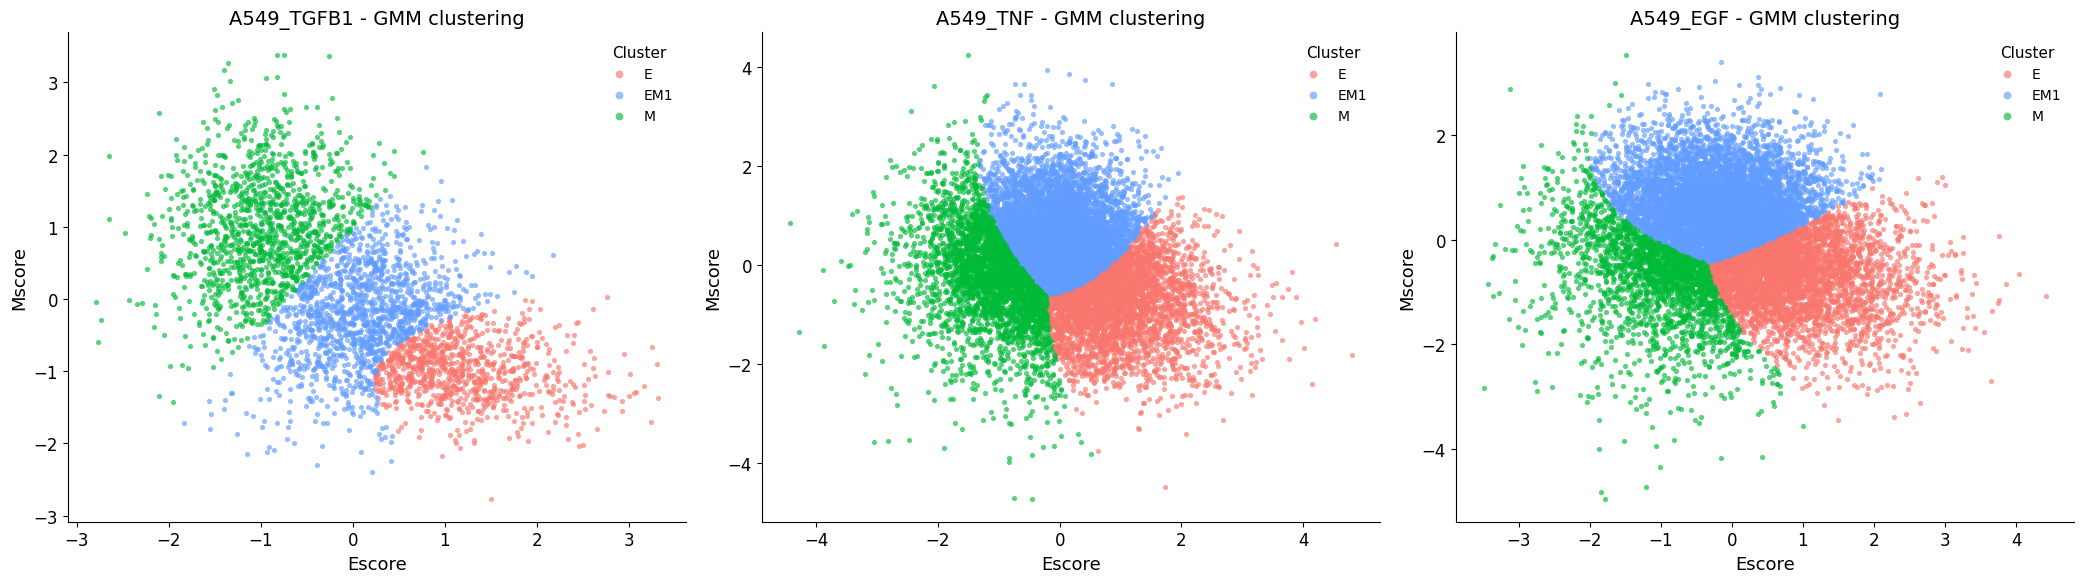

In [35]:
gmm_results = wf.build_gmm_in_em_space()


#### 3.2.1 Sankey: GMM cluster vs true timepoint label

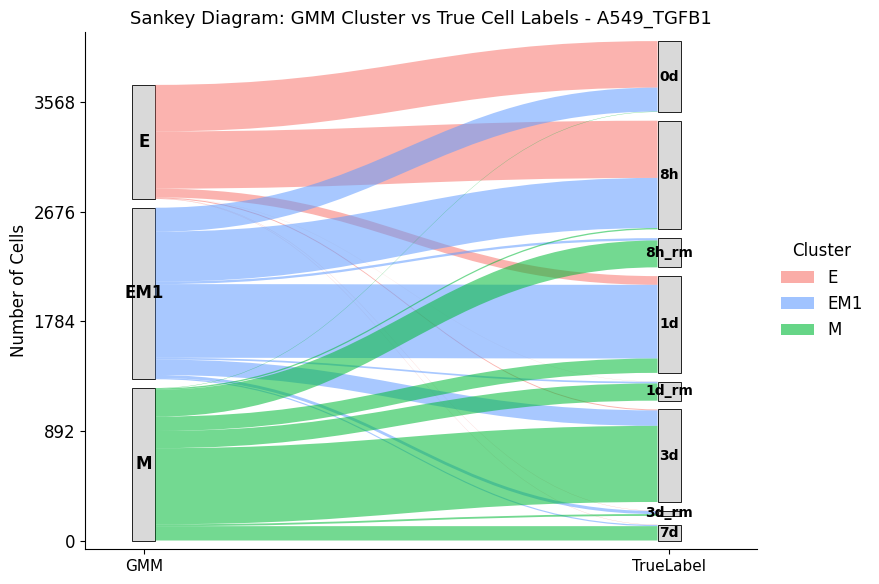

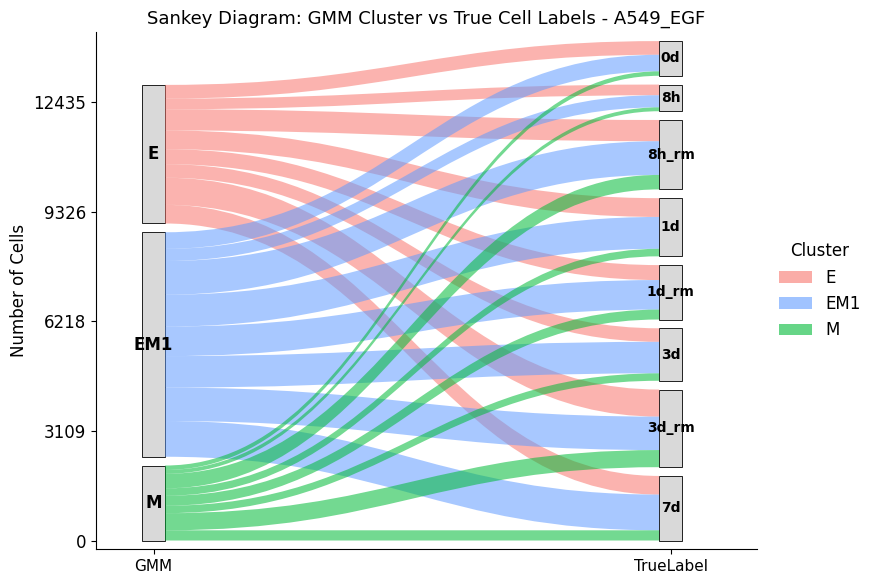

In [36]:
for fig in wf.plot_gmm_sankey(gmm_results, ['A549_TGFB1', 'A549_EGF']):
    display(fig)


### 3.3 Identifying Pathways Most Associated with the EMT Process

In [37]:
result = wf.run_pathway_correlation_v2()
display(result.head(10))


[geneExp] 15950 genes × 120 samples
[M signature] 193 unique genes

[Step 1] Computing single EMT score (M-signature top PC1)...
[EMT score] 120 samples (range: -10.559 to 39.790)

[Step 2] Filtering C2 pathways by M-overlap...
[overlap filter] kept 7537 / 7561 pathways (dropped 24 with > 30% overlap with EMT M signature)
   dropped: KOHN_EMT_MESENCHYMAL  (53.3% in M)
   dropped: WALLACE_PROSTATE_CANCER_DN  (50.0% in M)
   dropped: KEGG_MEDICUS_REFERENCE_REGULATION_OF_FIBRINOLYTIC_SYSTEM_C1INH  (50.0% in M)
   dropped: MIKKELSEN_DEDIFFERENTIATED_STATE_DN  (42.9% in M)
   dropped: NADELLA_PRKAR1A_TARGETS_DN  (42.9% in M)

[Step 3] Scoring filtered C2 pathways...
  scored 500/7537 pathways...
  scored 1000/7537 pathways...
  scored 1500/7537 pathways...
  scored 2000/7537 pathways...
  scored 2500/7537 pathways...
  scored 3000/7537 pathways...
  scored 3500/7537 pathways...
  scored 4000/7537 pathways...
  scored 4500/7537 pathways...
  scored 5000/7537 pathways...
  scored 5500/7537 pa

,Pathway,Correlation,P_value,Pathway_in_score_mat1,Pathway_in_score_mat2
0,LINDGREN_BLADDER_CANCER_CLUSTER_2B,0.966770,9.571727e-72,LINDGREN_BLADDER_CANCER_CLUSTER_2B,EMT_M_PC1
1,LIM_MAMMARY_STEM_CELL_UP,0.963397,2.605909e-69,LIM_MAMMARY_STEM_CELL_UP,EMT_M_PC1
2,BOQUEST_STEM_CELL_UP,0.960300,2.870759e-67,BOQUEST_STEM_CELL_UP,EMT_M_PC1
3,SCHUETZ_BREAST_CANCER_DUCTAL_INVASIVE_UP,0.960090,3.893197e-67,SCHUETZ_BREAST_CANCER_DUCTAL_INVASIVE_UP,EMT_M_PC1
4,CHARAFE_BREAST_CANCER_LUMINAL_VS_MESENCHYMAL_DN,0.956744,4.082420e-65,CHARAFE_BREAST_CANCER_LUMINAL_VS_MESENCHYMAL_DN,EMT_M_PC1
5,HOLLERN_EMT_BREAST_TUMOR_UP,0.956282,7.541805e-65,HOLLERN_EMT_BREAST_TUMOR_UP,EMT_M_PC1
6,FOROUTAN_INTEGRATED_TGFB_EMT_UP,0.955694,1.630495e-64,FOROUTAN_INTEGRATED_TGFB_EMT_UP,EMT_M_PC1
7,FOROUTAN_TGFB_EMT_UP,0.955138,3.350700e-64,FOROUTAN_TGFB_EMT_UP,EMT_M_PC1
8,SWEET_LUNG_CANCER_KRAS_DN,0.953895,1.620676e-63,SWEET_LUNG_CANCER_KRAS_DN,EMT_M_PC1
9,FOROUTAN_PRODRANK_TGFB_EMT_UP,0.951630,2.568140e-62,FOROUTAN_PRODRANK_TGFB_EMT_UP,EMT_M_PC1


#### 3.3.1 Top 10 Positively Correlated Pathways

In [38]:
wf.plot_top_pathways(result, n=10, mode='positive',
                     title='Top 10 Positive Correlated Pathways').show()


#### 3.3.2 Top 10 Negatively Correlated Pathways

In [39]:
wf.plot_top_pathways(result, n=10, mode='negative',
                     title='Top 10 Negative Correlated Pathways').show()


### 3.4 E vs M and PC1 vs PC2 Scatter Plots

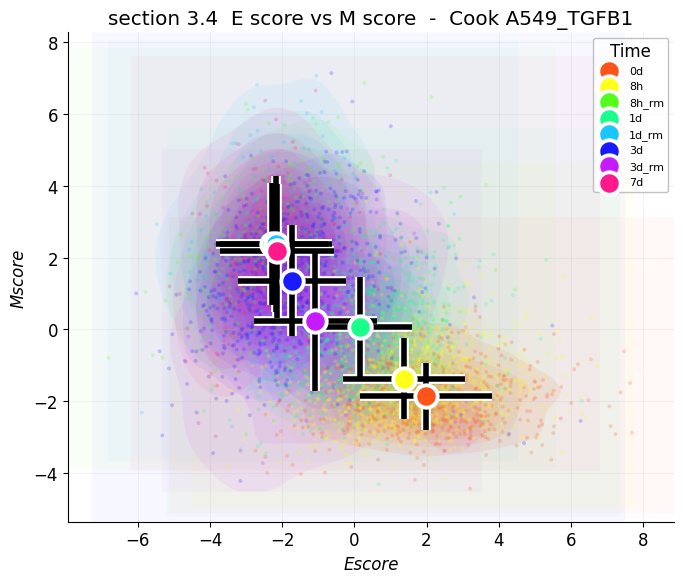

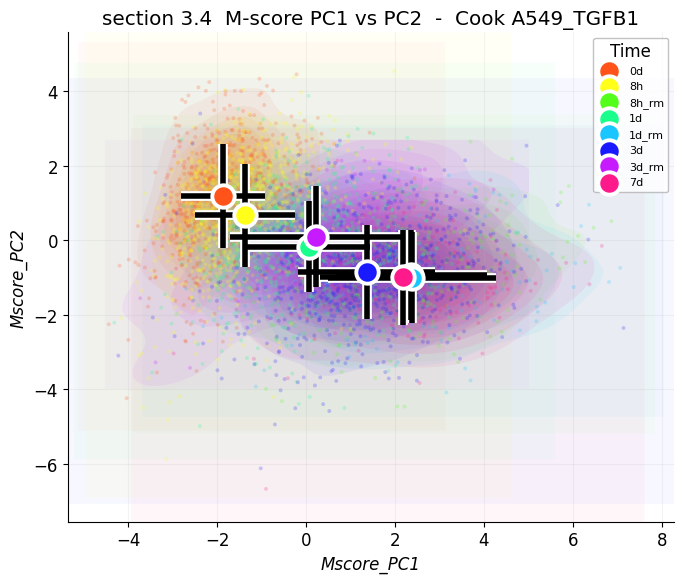

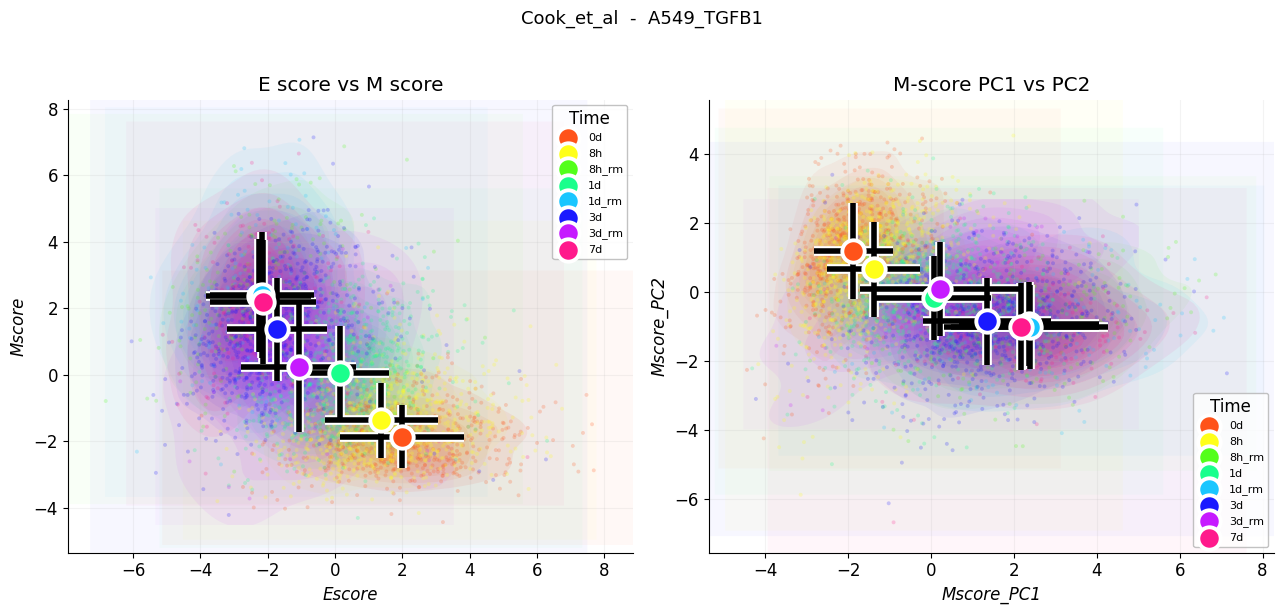

In [40]:
fig_a, fig_b, fig_c, adata_sc = wf.plot_em_pc_panels_cook()
display(fig_a); display(fig_b); display(fig_c)


### 3.5 Computing Additional Scores (Stemness and Senescence)

In [41]:
adata_sc = wf.compute_stem_senescence(adata_sc)


### 3.6 Relationship Between Stemness, Senescence, and EMT Scores

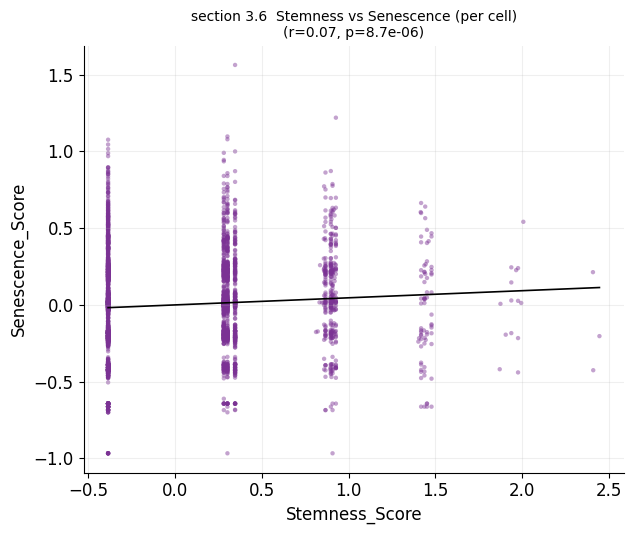

In [42]:
display(wf.plot_stemness_vs_senescence(adata_sc))


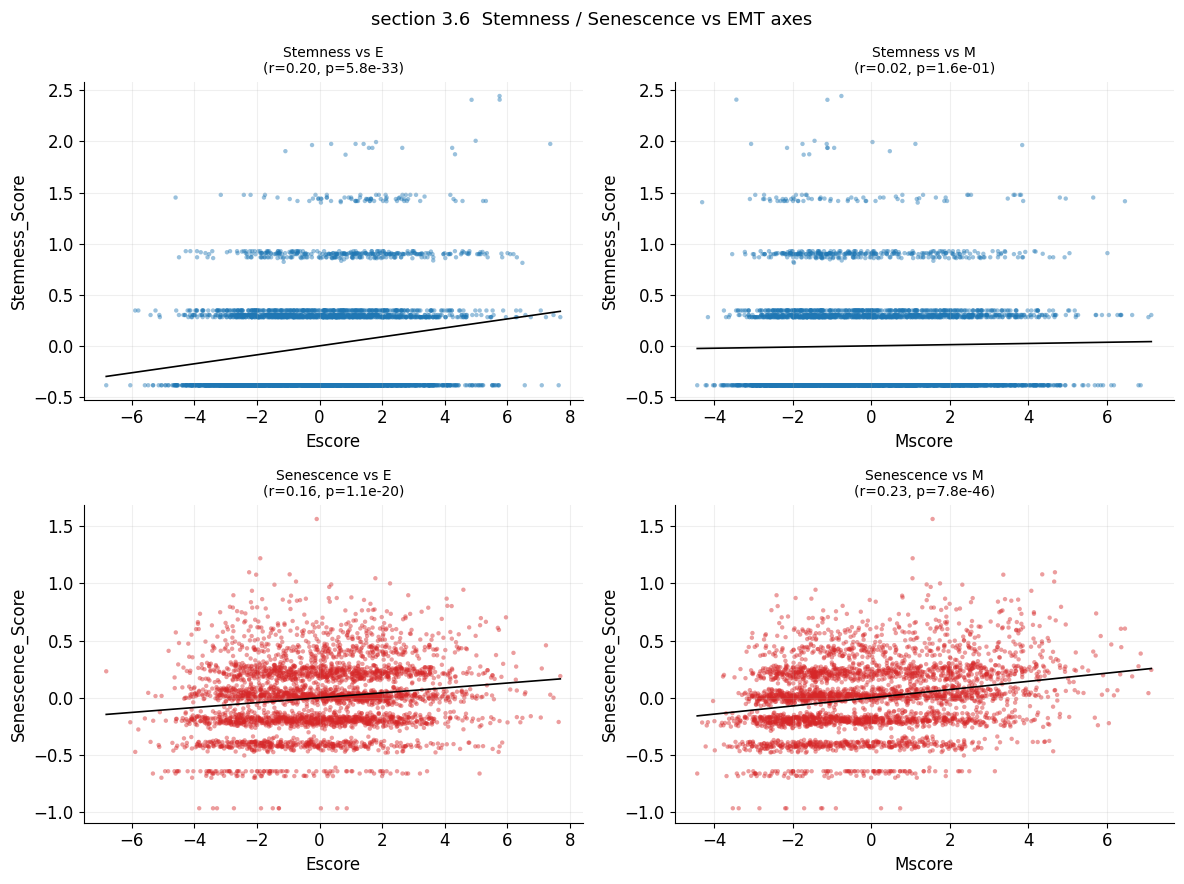

In [43]:
display(wf.plot_em_vs_stem_sen(adata_sc))
